In [1]:
from mpasdiag import MPAS3DProcessor, MPASConfig, GeographicBounds, MoistureTransportDiagnostics, MPASSurfacePlotter, SurfaceMapStyle, MPASWindPlotter


In [2]:
proc = MPAS3DProcessor(grid_file="../data/grids/x1.10242.static.nc", verbose=True)
proc.load_3d_data("../data/u240k/mpasout")

In [3]:
tindex = 0
qv = proc.dataset["qv"].isel(Time=tindex)
# Total pressure = perturbation + base state
pressure = (proc.dataset["pressure_p"].isel(Time=tindex)
            + proc.dataset["pressure_base"].isel(Time=tindex))
u_3d = proc.dataset["uReconstructZonal"].isel(Time=tindex)
v_3d = proc.dataset["uReconstructMeridional"].isel(Time=tindex)

In [4]:
# Diagnostic: IWV, IVT_u, IVT_v, IVT magnitude
diag = MoistureTransportDiagnostics(verbose=True)
result = diag.analyze_moisture_transport(qv, u_3d, v_3d, pressure)
ivt_mag = result["ivt"]["data"]
ivt_u   = result["ivt_u"]["data"]
ivt_v   = result["ivt_v"]["data"]

In [5]:
lon, lat = proc.extract_2d_coordinates_for_variable("qv", ivt_u)


In [6]:
cfg = MPASConfig()
cfg.lon_min, cfg.lon_max = -180, 180
cfg.lat_min, cfg.lat_max =  -90,  90
cfg.remap_engine, cfg.remap_method = "kdtree", "nearest"
bounds = GeographicBounds(cfg.lon_min, cfg.lon_max, cfg.lat_min, cfg.lat_max)

Wind data may not be in m/s. Consider specifying 'original_units' in config.


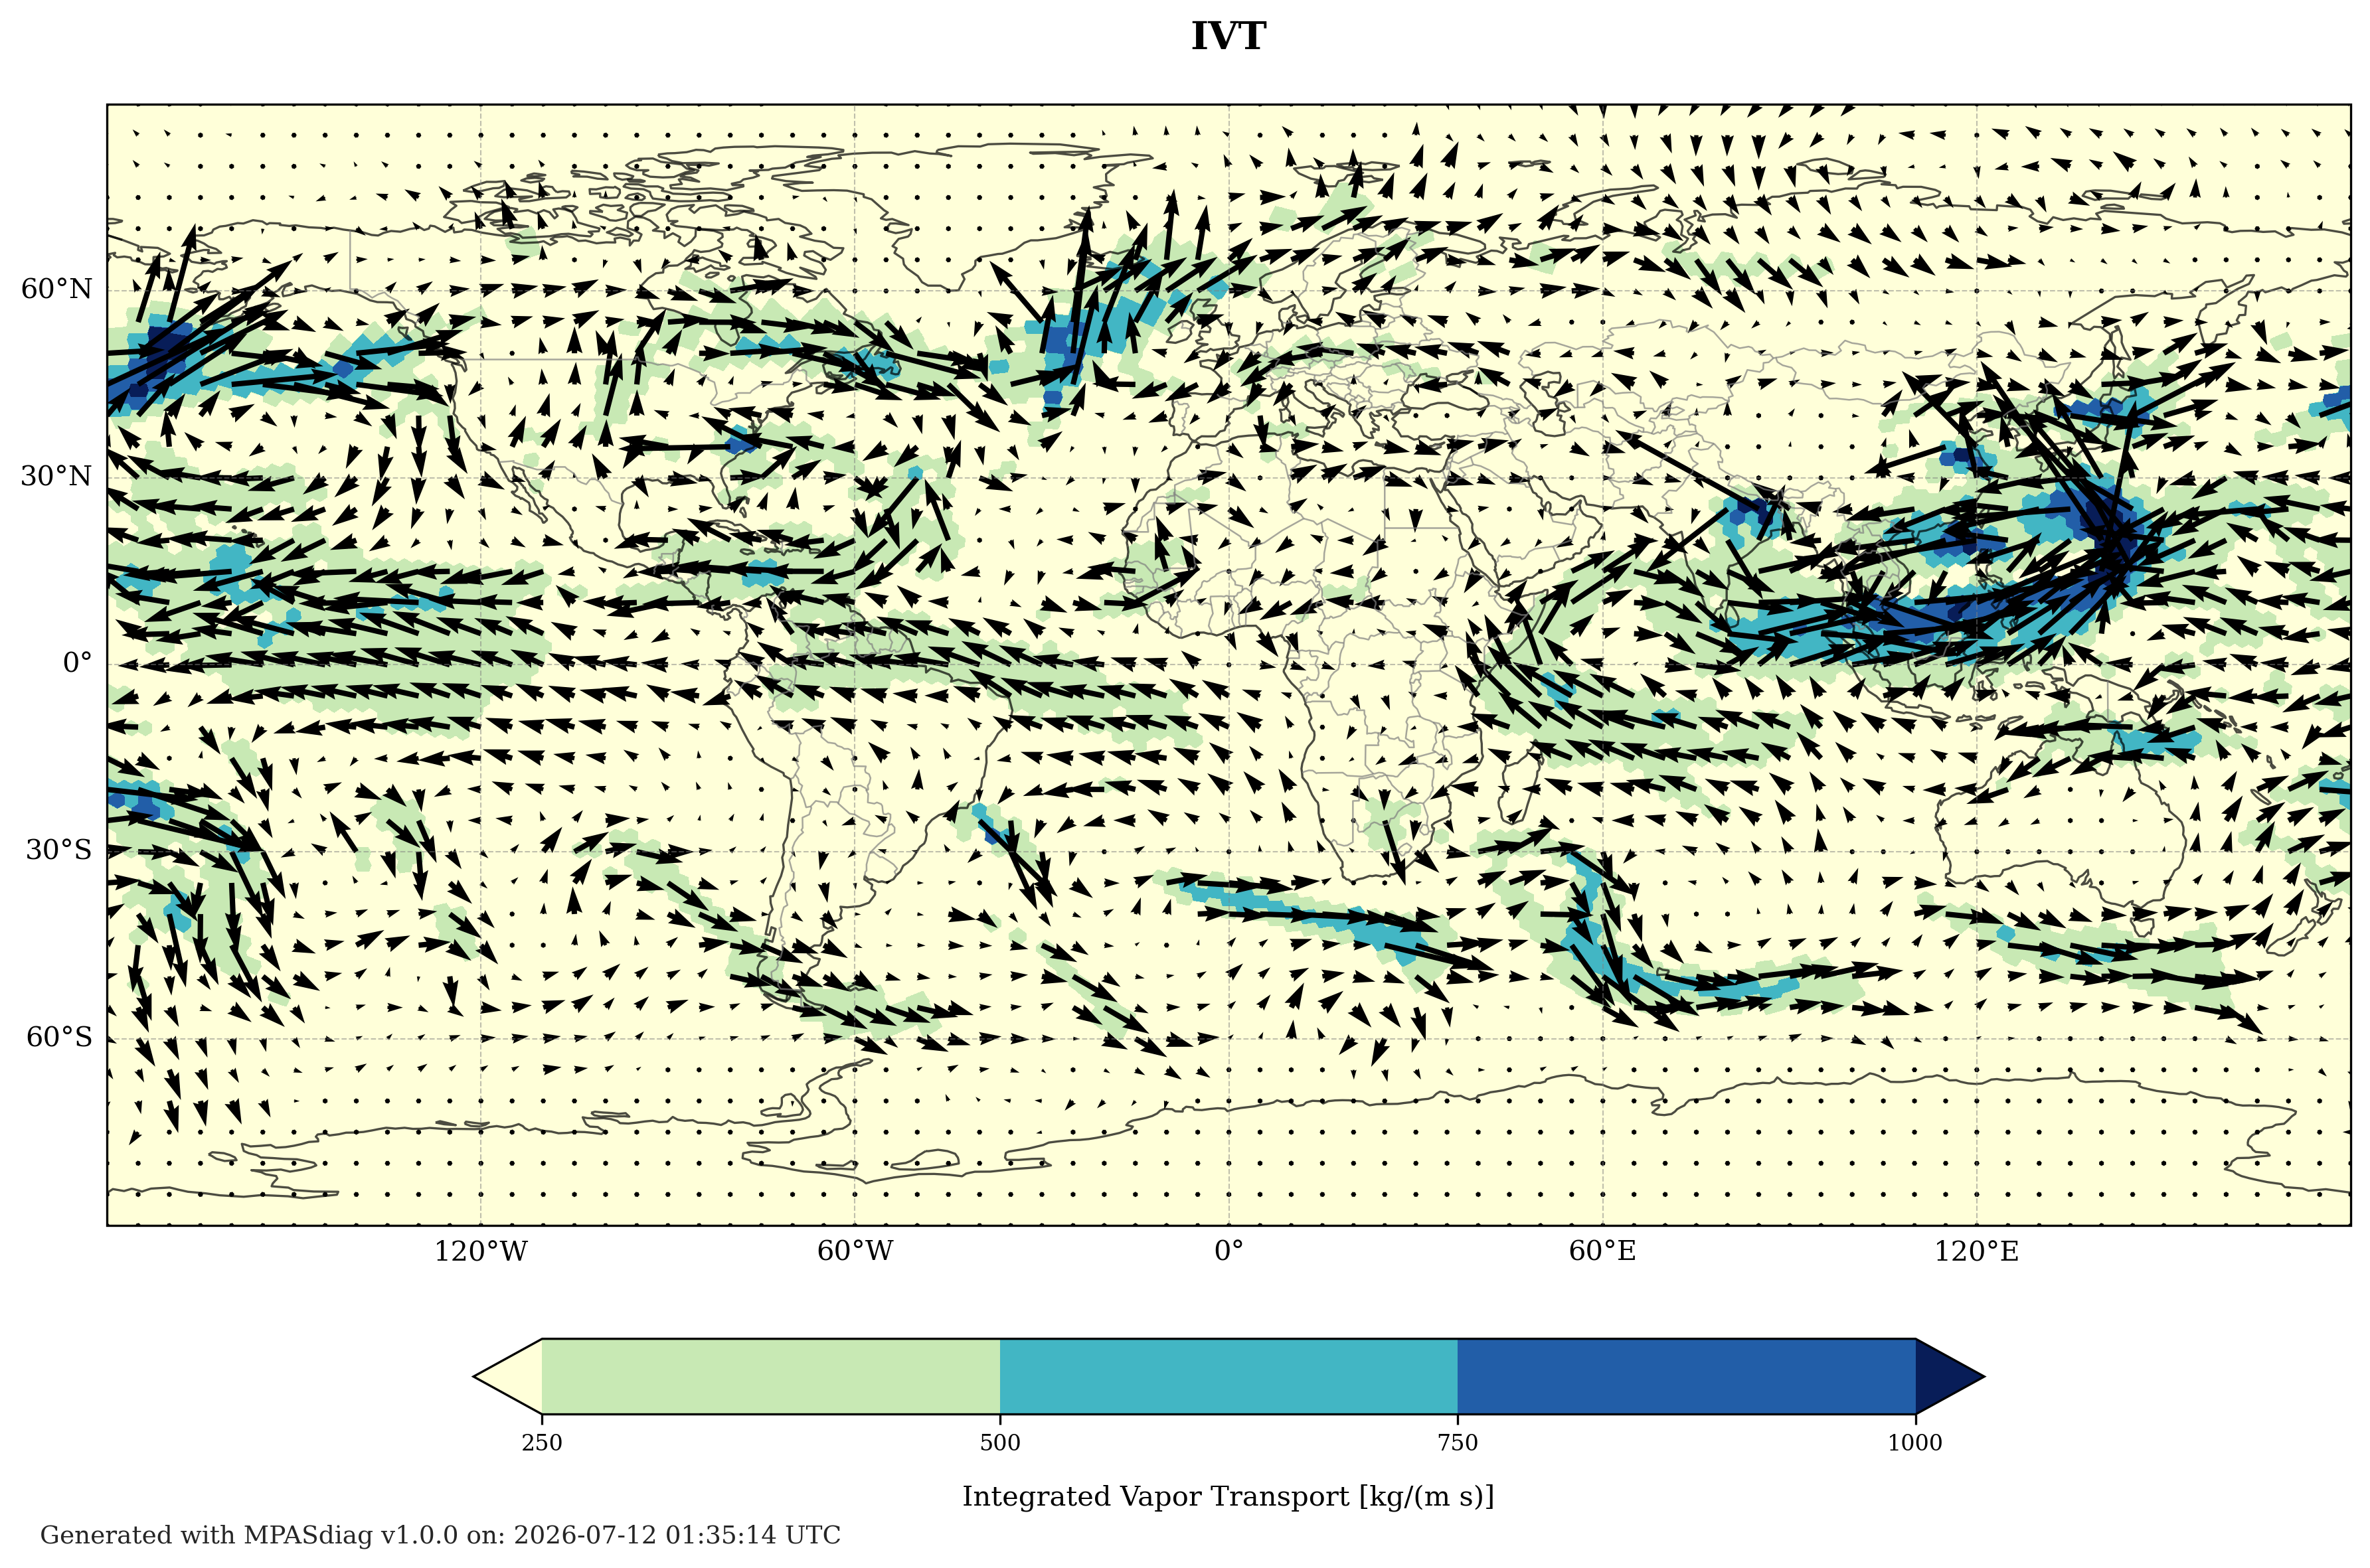

In [9]:
# Base layer: IVT magnitude shading
plotter = MPASSurfacePlotter(figsize=(12, 9), dpi=300)
fig, ax = plotter.create_surface_map(
    lon=lon, lat=lat, data=ivt_mag.values.flatten(), var_name="ivt",
    bounds=bounds, config=cfg,
    style=SurfaceMapStyle(plot_type="contourf", grid_resolution=0.1,
                          levels=[250, 500, 750, 1000], title="IVT"),
)
# Overlay layer: IVT direction as arrows (a dict-configured overlay)
wind = MPASWindPlotter(figsize=(12, 9), dpi=300)
Q = wind.add_wind_overlay(
    ax, lon, lat,
    {"u_data": ivt_u.values.flatten(), "v_data": ivt_v.values.flatten(),
     "plot_type": "arrows", "subsample": "-1", "scale": 15000,
     "colors": "black", "grid_resolution": 0.1},
    lon_min=cfg.lon_min, lon_max=cfg.lon_max,
    lat_min=cfg.lat_min, lat_max=cfg.lat_max, config=cfg,
)

In [10]:
plotter.save_plot("./output/ivt_map", formats=["png"])
plotter.close_plot()